# Previsão de Séries Temporais com LSTM e GRU

Este projeto tem como objetivo prever o preço de ações utilizando redes neurais recorrentes (LSTM e GRU), com base em dados históricos do mercado financeiro.

In [23]:
## Importação das bibliotecas
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, GRU, Dense

import yfinance as yf

In [25]:
## Coleta de dados
acao = "PETR4.SA"

df = yf.download(
    acao,
    start="2015-01-01",
    end="2024-12-31"
)

df.head()

/tmp/ipykernel_732/3304662881.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,PETR4.SA,PETR4.SA,PETR4.SA,PETR4.SA,PETR4.SA
Date,,,,,
2015-01-02,2.493752,2.661600,2.491088,2.661600,49559500
2015-01-05,2.280611,2.448459,2.272618,2.435138,78385100
2015-01-06,2.206011,2.352546,2.142069,2.320575,84723300
2015-01-07,2.309917,2.325903,2.227325,2.280611,85531000
2015-01-08,2.459116,2.501744,2.328567,2.341888,83306300


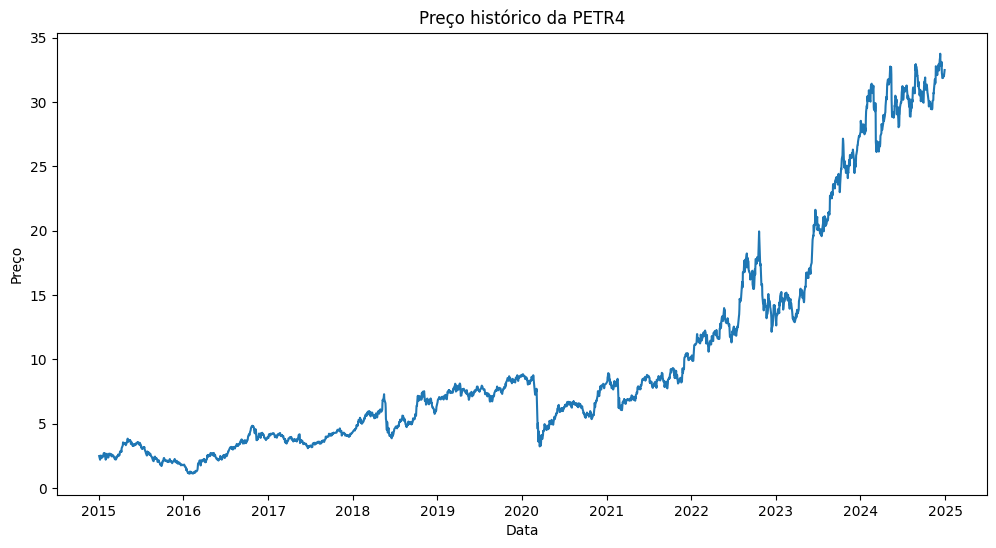

In [3]:
## Análise exploratória
plt.figure(figsize=(12,6))

plt.plot(df["Close"])

plt.title("Preço histórico da PETR4")

plt.xlabel("Data")
plt.ylabel("Preço")

plt.show()

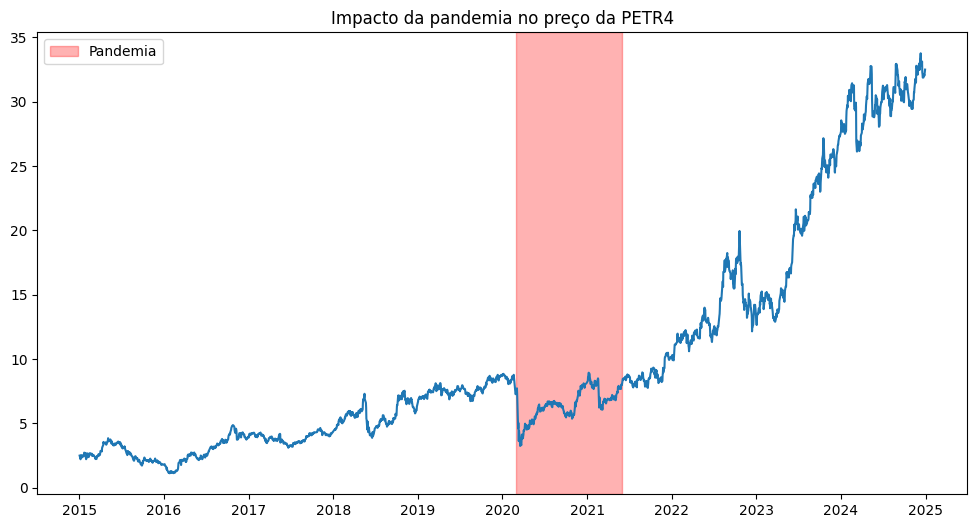

In [4]:
## Impacto da pandemia
plt.figure(figsize=(12,6))

plt.plot(df["Close"])

plt.axvspan("2020-03-01","2021-06-01",
            color="red",
            alpha=0.3,
            label="Pandemia")

plt.legend()

plt.title("Impacto da pandemia no preço da PETR4")

plt.show()

In [5]:
## Seleção da variável
# variável preço de fechamento (Close)
data = df["Close"].values

data = data.reshape(-1,1)

In [6]:
## Normalização dos dados
scaler = MinMaxScaler()

data_scaled = scaler.fit_transform(data)

In [7]:
## Criação de janelas temporais
X = []
y = []

janela = 60

for i in range(janela, len(data_scaled)):

    X.append(data_scaled[i-janela:i])

    y.append(data_scaled[i])

X = np.array(X)
y = np.array(y)

In [8]:
## Separação dos dados
train_size = int(len(X)*0.8)

X_train = X[:train_size]
X_test = X[train_size:]

y_train = y[:train_size]
y_test = y[train_size:]

In [9]:
## Modelo LSTM
model_lstm = Sequential()

model_lstm.add(
    LSTM(
        50,
        input_shape=(X.shape[1],1)
    )
)

model_lstm.add(Dense(1))

model_lstm.compile(
    optimizer="adam",
    loss="mean_squared_error"
)

history_lstm = model_lstm.fit(
    X_train,
    y_train,
    epochs=15,
    batch_size=32
)

Epoch 1/15


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


61/61 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - loss: 0.0041
Epoch 2/15
61/61 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 2.4359e-04
Epoch 3/15
61/61 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - loss: 2.0765e-04
Epoch 4/15
61/61 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - loss: 1.9280e-04
Epoch 5/15
61/61 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - loss: 1.9068e-04
Epoch 6/15
61/61 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - loss: 1.7884e-04
Epoch 7/15
61/61 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 1.6069e-04
Epoch 8/15
61/61 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - loss: 1.5634e-04
Epoch 9/15
61/61 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 1.4301e-04
Epoch 10/15
61/61 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 1.4303e-04
Epoch 11/15
61/61 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - loss: 1.3259e-04
Epoch 12/15
61/61 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - loss: 1.2883e-04
Epoch 13/15
61/61 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - loss: 1.1327e-04
Epoch 14/15
61/61 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - loss: 1.1447e-04
Epoch 15/15
61/61 ━━━━━━━━━━━━

In [10]:
## Modelo GRU
model_gru = Sequential()

model_gru.add(
    GRU(
        50,
        input_shape=(X.shape[1],1)
    )
)

model_gru.add(Dense(1))

model_gru.compile(
    optimizer="adam",
    loss="mean_squared_error"
)

history_gru = model_gru.fit(
    X_train,
    y_train,
    epochs=15,
    batch_size=32
)

Epoch 1/15
61/61 ━━━━━━━━━━━━━━━━━━━━ 4s 31ms/step - loss: 0.0052
Epoch 2/15
61/61 ━━━━━━━━━━━━━━━━━━━━ 3s 47ms/step - loss: 1.1029e-04
Epoch 3/15
61/61 ━━━━━━━━━━━━━━━━━━━━ 4s 32ms/step - loss: 8.9757e-05
Epoch 4/15
61/61 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - loss: 8.4545e-05
Epoch 5/15
61/61 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - loss: 8.1578e-05
Epoch 6/15
61/61 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - loss: 7.9650e-05
Epoch 7/15
61/61 ━━━━━━━━━━━━━━━━━━━━ 3s 46ms/step - loss: 7.6259e-05
Epoch 8/15
61/61 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - loss: 7.1282e-05
Epoch 9/15
61/61 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - loss: 6.8551e-05
Epoch 10/15
61/61 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - loss: 6.6208e-05
Epoch 11/15
61/61 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - loss: 6.5511e-05
Epoch 12/15
61/61 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - loss: 6.2449e-05
Epoch 13/15
61/61 ━━━━━━━━━━━━━━━━━━━━ 3s 48ms/step - loss: 6.5407e-05
Epoch 14/15
61/61 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - loss: 5.9345e-05
Epoch 15/15
61/61 ━

In [11]:
## Geração de previsões
pred_lstm = model_lstm.predict(X_test)

pred_gru = model_gru.predict(X_test)

16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step


In [12]:
## Reversão da normalização
pred_lstm = scaler.inverse_transform(pred_lstm)

pred_gru = scaler.inverse_transform(pred_gru)

y_real = scaler.inverse_transform(y_test)

In [13]:
## Avaliação dos modelos (RMSE)
rmse_lstm = np.sqrt(mean_squared_error(y_real, pred_lstm))

rmse_gru = np.sqrt(mean_squared_error(y_real, pred_gru))

print("RMSE LSTM:", rmse_lstm)

print("RMSE GRU:", rmse_gru)

RMSE LSTM: 1.049347868400025
RMSE GRU: 0.5193493112190547


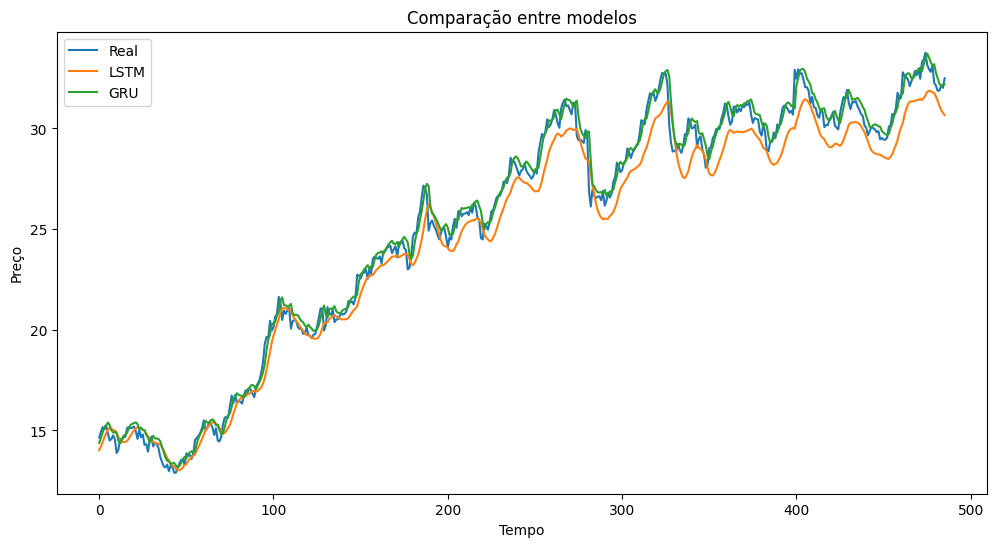

In [14]:
## Comparação dos resultados
plt.figure(figsize=(12,6))

plt.plot(y_real, label="Real")

plt.plot(pred_lstm, label="LSTM")

plt.plot(pred_gru, label="GRU")

plt.legend()

plt.title("Comparação entre modelos")

plt.xlabel("Tempo")

plt.ylabel("Preço")

plt.show()

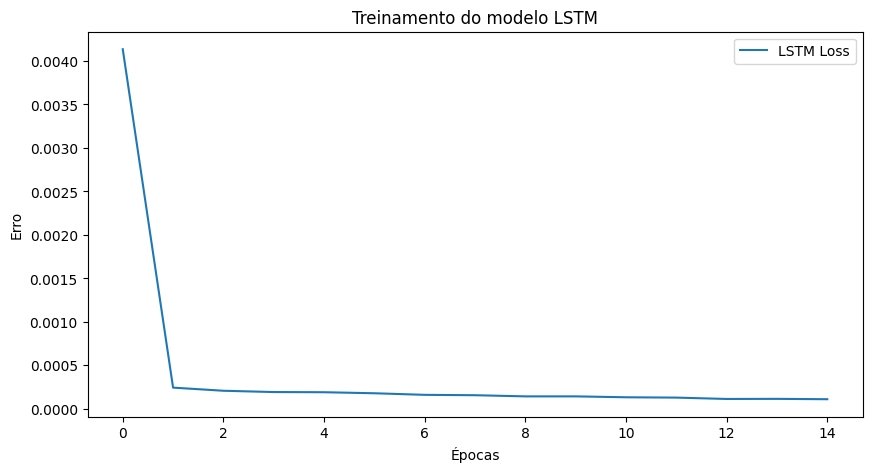

In [15]:
## Análise do treinamento LSTM
plt.figure(figsize=(10,5))

plt.plot(history_lstm.history['loss'], label='LSTM Loss')

plt.title('Treinamento do modelo LSTM')

plt.xlabel('Épocas')
plt.ylabel('Erro')

plt.legend()

plt.show()

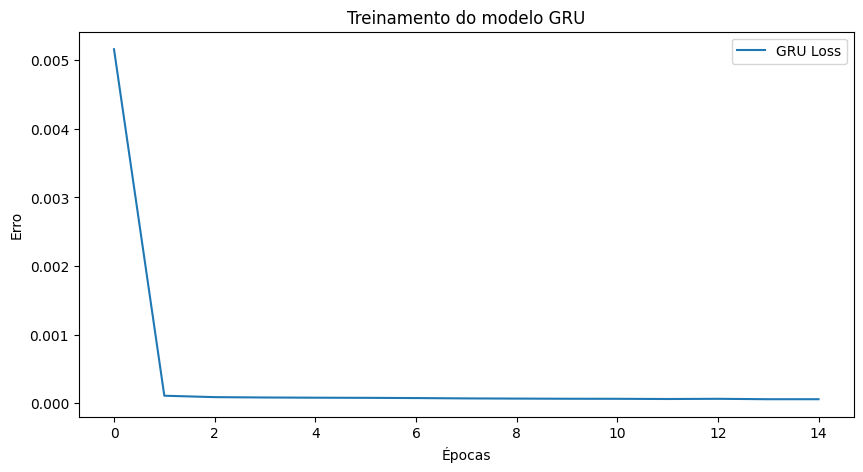

In [16]:
## Análise do treinamento GRU
plt.figure(figsize=(10,5))

plt.plot(history_gru.history['loss'], label='GRU Loss')

plt.title('Treinamento do modelo GRU')

plt.xlabel('Épocas')
plt.ylabel('Erro')

plt.legend()

plt.show()

In [17]:
## Preparação dos dados de entrada
last_60_days = data_scaled[-60:]

X_future = []

X_future.append(last_60_days)

X_future = np.array(X_future)

In [18]:
## Geração das previsões
future_predictions = []

current_input = last_60_days.copy()

for i in range(30):

    current_input_reshaped = current_input.reshape(1,60,1)

    next_pred = model_lstm.predict(current_input_reshaped)

    future_predictions.append(next_pred[0,0])

    current_input = np.append(current_input[1:], next_pred, axis=0)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━

In [19]:
## Reversão da normalização
future_predictions = scaler.inverse_transform(
    np.array(future_predictions).reshape(-1,1)
)

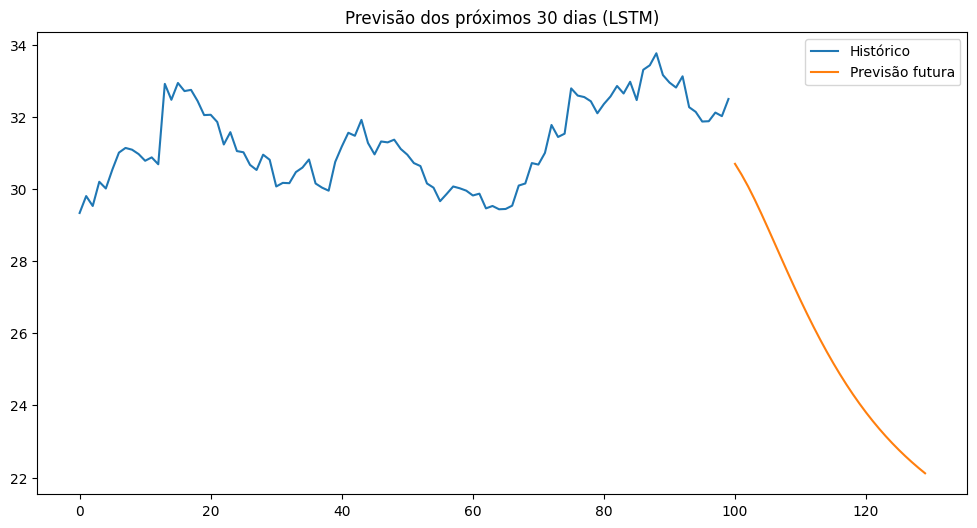

In [20]:
## Visualização da previsão futura
plt.figure(figsize=(12,6))

plt.plot(data[-100:], label="Histórico")

plt.plot(
    range(100, 130),
    future_predictions,
    label="Previsão futura"
)

plt.legend()

plt.title("Previsão dos próximos 30 dias (LSTM)")

plt.show()

## Conclusão

Os resultados indicam que o modelo GRU apresentou melhor desempenho em relação ao LSTM, com menor erro de previsão. O projeto demonstrou a aplicação de redes neurais recorrentes na previsão de séries temporais financeiras.